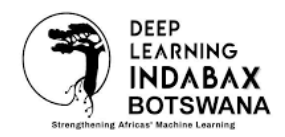

# Exploratory Data Analysis in Python

### Deep Learning IndabaX Botswana &nbsp;·&nbsp; *Strengthening Africa's Machine Learning*

A complete, runnable walkthrough of all four EDA chapters, applied to a real dataset of Indian regional unemployment (Jan–Oct 2020).

1. **Getting to Know a Dataset** — initial exploration, validation, summarization
2. **Data Cleaning & Manipulation** — missing data, type conversion, outliers
3. **Relationships in Data** — time patterns, correlation, distributions
4. **Turning Exploratory Analysis into Action** — class balance, cross-tabs, features, hypotheses

> **How to run:** keep `unemp_upto_11_2020.csv` in the same folder as this notebook, then run the cells top to bottom (Kernel → Restart & Run All). Outputs have been cleared to keep the file lightweight and quick to open.

---


### Uploading the `unemp_upto_11_2020.csv` file

To ensure the notebook runs correctly, you need to upload the `unemp_upto_11_2020.csv` file. You can do this either by dragging and dropping it into the file browser (folder icon on the left sidebar) or by running the following Python code, which will prompt you to select the file from your local machine.

In [3]:
from google.colab import files

# This will prompt you to upload the file
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving unemp_upto_11_2020.csv to unemp_upto_11_2020.csv
User uploaded file "unemp_upto_11_2020.csv" with length 18274 bytes


## Setup

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Load the raw file
unemp = pd.read_csv("unemp_upto_11_2020.csv")

# The raw headers have stray spaces and a duplicated "Region" column.
# Clean the column names and rename for clarity.
unemp.columns = unemp.columns.str.strip()
unemp = unemp.rename(columns={
    "Region": "State",
    "Region.1": "Zone",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

# Strip whitespace from string values
for col in ["State", "Frequency", "Zone", "Date"]:
    unemp[col] = unemp[col].str.strip()

unemp.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


---
# Chapter 1 — Getting to Know a Dataset

Goal: understand the shape, types, and content of the data before doing anything else.

### 1.1 Initial exploration: `.head()`, `.info()`, `.describe()`

In [5]:
# A first look at the top rows
unemp.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
# Structure: row count, column names, dtypes, and non-null counts
unemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      267 non-null    object 
 1   Date                       267 non-null    object 
 2   Frequency                  267 non-null    object 
 3   Unemployment_Rate          267 non-null    float64
 4   Employed                   267 non-null    int64  
 5   Labour_Participation_Rate  267 non-null    float64
 6   Zone                       267 non-null    object 
 7   longitude                  267 non-null    float64
 8   latitude                   267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [7]:
# Summary statistics for the numeric columns
unemp.describe()

,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


### 1.2 Counting categorical values with `.value_counts()`

In [8]:
# How many observations fall in each zone?
print(unemp["Zone"].value_counts())

# Number of unique states
print("\nUnique states:", unemp["State"].nunique())

Zone
North        79
South        60
West         50
East         40
Northeast    38
Name: count, dtype: int64

Unique states: 27


### 1.3 A grouped summary (the "Global unemployment" idea)

The course's *Global unemployment in 2021* exercise counts categories and summarises a numeric column by group. Here we look at average unemployment by zone.

In [9]:
zone_summary = unemp.groupby("Zone")["Unemployment_Rate"].mean().sort_values(ascending=False)
print(zone_summary)

Zone
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Unemployment_Rate, dtype: float64


### 1.4 Data validation — detecting data types

In [10]:
# .dtypes gives a compact view of every column's type
unemp.dtypes

,0
State,object
Date,object
Frequency,object
Unemployment_Rate,float64
Employed,int64
Labour_Participation_Rate,float64
Zone,object
longitude,float64
latitude,float64


**Detecting a type problem.** `Date` is stored as an `object` (string). To analyse patterns over time we need a real datetime. We fix this in Chapter 3.

### 1.5 Validating categories with `.isin()`

In [11]:
# Which rows belong to the recognised geographic zones?
valid_zones = ["North", "South", "East", "West", "Northeast"]
print(unemp["Zone"].isin(valid_zones).all(), "- all rows use a valid zone")

# The ~ operator inverts the mask: rows NOT in the list (should be empty here)
unexpected = unemp[~unemp["Zone"].isin(valid_zones)]
print("Rows with an unexpected zone:", len(unexpected))

True - all rows use a valid zone
Rows with an unexpected zone: 0


### 1.6 Validating numerical ranges — `.min()`, `.max()`, boxplot

Unemployment rate range: 0.5 to 75.85


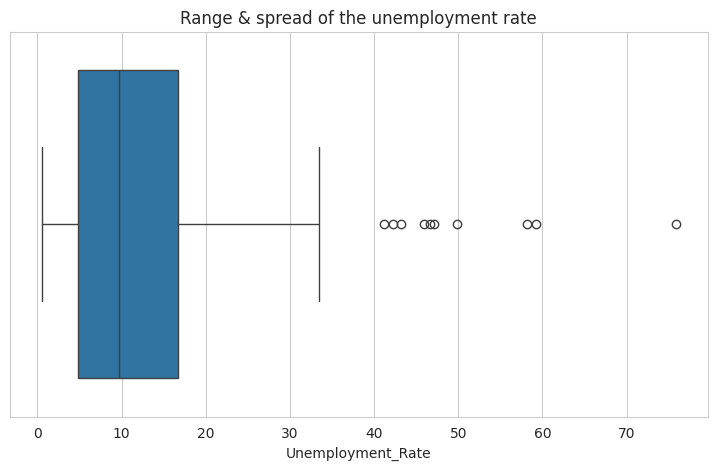

In [12]:
print("Unemployment rate range:",
      unemp["Unemployment_Rate"].min(), "to", unemp["Unemployment_Rate"].max())

sns.boxplot(data=unemp, x="Unemployment_Rate")
plt.title("Range & spread of the unemployment rate")
plt.show()

### 1.7 Data summarization with `.groupby()` and `.agg()`

In [13]:
# Multiple statistics for one column, per zone
unemp.groupby("Zone")["Unemployment_Rate"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Zone,,,,
East,13.916000,13.288121,1.42,59.23
North,15.889620,8.094080,2.20,43.22
Northeast,10.950263,10.820467,0.60,41.23
South,10.454667,13.661697,0.50,75.85
West,8.239000,5.505498,1.84,21.98


#### Named aggregations (clean, readable column names)

In [14]:
zone_stats = unemp.groupby("Zone").agg(
    mean_unemployment=("Unemployment_Rate", "mean"),
    std_unemployment=("Unemployment_Rate", "std"),
    median_participation=("Labour_Participation_Rate", "median"),
    total_employed=("Employed", "sum"),
)
zone_stats

,mean_unemployment,std_unemployment,median_participation,total_employed
Zone,,,,
East,13.916000,13.288121,39.390,784094676
North,15.889620,8.094080,39.420,1032726546
Northeast,10.950263,10.820467,50.985,137450010
South,10.454667,13.661697,39.045,842435360
West,8.239000,5.505498,41.355,931175636


### 1.8 Visualizing categorical summaries

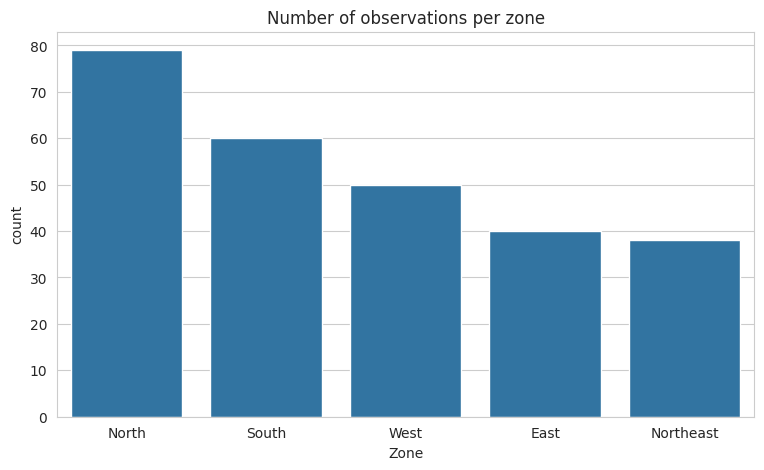

In [15]:
# Frequency of each zone
sns.countplot(data=unemp, x="Zone", order=unemp["Zone"].value_counts().index)
plt.title("Number of observations per zone")
plt.show()

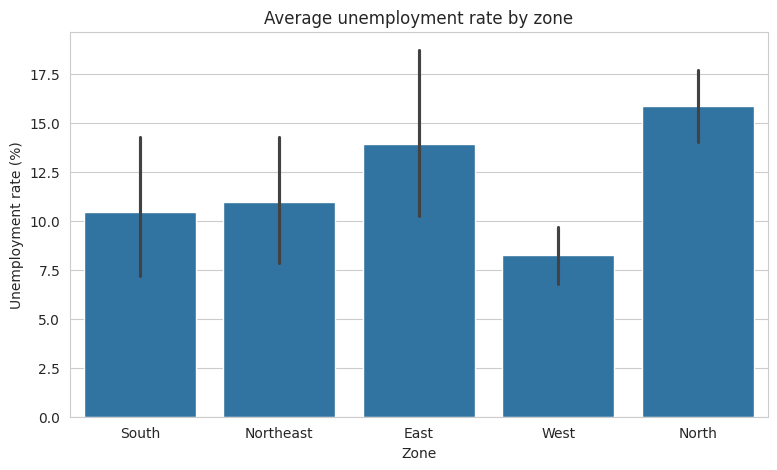

In [16]:
# barplot shows the MEAN of a numeric value per category (with error bars)
sns.barplot(data=unemp, x="Zone", y="Unemployment_Rate")
plt.title("Average unemployment rate by zone")
plt.ylabel("Unemployment rate (%)")
plt.show()

---
# Chapter 2 — Data Cleaning and Manipulation

Handling missing values, converting types, engineering categories, and dealing with outliers.

### 2.1 Addressing missing data — checking for it

In [17]:
# Count missing values per column
print(unemp.isna().sum())

State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Zone                         0
longitude                    0
latitude                     0
dtype: int64


This dataset is fairly complete, so we **inject a few missing values** to demonstrate every strategy from the course, then treat them exactly as George does with `salaries`.

In [18]:
# Make a working copy and knock out some values for the demo
demo = unemp.copy()
rng = np.random.default_rng(42)
demo.loc[rng.choice(demo.index, 8, replace=False), "Labour_Participation_Rate"] = np.nan
demo.loc[rng.choice(demo.index, 20, replace=False), "Unemployment_Rate"] = np.nan

print(demo.isna().sum())

State                         0
Date                          0
Frequency                     0
Unemployment_Rate            20
Employed                      0
Labour_Participation_Rate     8
Zone                          0
longitude                     0
latitude                      0
dtype: int64


### 2.2 Strategy 1 — Drop columns/rows missing ≤ 5% of values

The rule of thumb: if a column is missing **5% or less** of its values, dropping those rows is safe.

In [19]:
threshold = len(demo) * 0.05
print("5% threshold =", threshold, "rows")

# Columns whose missing count is at or below the threshold -> safe to drop rows
cols_to_drop = demo.columns[demo.isna().sum() <= threshold]
print("Drop rows missing values in:", list(cols_to_drop))

demo.dropna(subset=cols_to_drop, inplace=True)
print(demo.isna().sum())

5% threshold = 13.350000000000001 rows
Drop rows missing values in: ['State', 'Date', 'Frequency', 'Employed', 'Labour_Participation_Rate', 'Zone', 'longitude', 'latitude']
State                         0
Date                          0
Frequency                     0
Unemployment_Rate            20
Employed                      0
Labour_Participation_Rate     0
Zone                          0
longitude                     0
latitude                      0
dtype: int64


### 2.3 Strategy 2 — Impute a summary statistic

For remaining gaps, fill with a representative value. Use the **mode** for categoricals and **mean/median** for numerics (median is safer when the distribution is skewed, as unemployment is).

In [20]:
# Columns that still have missing values
cols_with_missing = demo.columns[demo.isna().sum() > 0]
print("Still missing:", list(cols_with_missing))

# Median imputation for the skewed unemployment rate
median_rate = demo["Unemployment_Rate"].median()
demo["Unemployment_Rate"] = demo["Unemployment_Rate"].fillna(median_rate)
print("Remaining missing:", demo["Unemployment_Rate"].isna().sum())

Still missing: ['Unemployment_Rate']
Remaining missing: 0


### 2.4 Strategy 3 — Impute by sub-group

A single median ignores that zones differ. Better: fill each missing value with **its own zone's median**, mirroring the course's "different experience levels have different median salary" logic.

In [21]:
# Rebuild the demo gaps to show sub-group imputation cleanly
demo2 = unemp.copy()
demo2.loc[rng.choice(demo2.index, 25, replace=False), "Unemployment_Rate"] = np.nan

# Median unemployment per zone -> dict
zone_medians = demo2.groupby("Zone")["Unemployment_Rate"].median().to_dict()
print(zone_medians)

# Map each row's zone to its median and use that to fill the gaps
demo2["Unemployment_Rate"] = demo2["Unemployment_Rate"].fillna(
    demo2["Zone"].map(zone_medians)
)
print("\nMissing after sub-group imputation:", demo2["Unemployment_Rate"].isna().sum())

{'East': 10.135, 'North': 15.545, 'Northeast': 5.615, 'South': 5.87, 'West': 6.305}

Missing after sub-group imputation: 0


### 2.5 Converting & analyzing categorical data — `.str.contains()`

In [22]:
# Search a text column for a phrase -> boolean mask
# e.g. flag the union-territory / metro-style names containing "Pradesh"
unemp["State"].str.contains("Pradesh").sum()

np.int64(40)

In [23]:
# Multiple phrases with the | (OR) operator
unemp["State"].str.contains("Delhi|Haryana|Punjab").sum()

np.int64(30)

#### Building a new categorical column with `np.select()`

The course groups 50 job titles into 6 categories. We group 27 states into broad **region labels** using conditions + `np.select`.

In [24]:
# Define regex patterns for each target category
north = "Punjab|Haryana|Delhi|Himachal|Rajasthan|Uttar|Jammu|Chandigarh"
south = "Andhra|Telangana|Karnataka|Kerala|Tamil|Puducherry"
east  = "Bihar|Jharkhand|Odisha|West Bengal"
west  = "Gujarat|Maharashtra|Goa|Madhya|Chhattisgarh"

conditions = [
    unemp["State"].str.contains(north),
    unemp["State"].str.contains(south),
    unemp["State"].str.contains(east),
    unemp["State"].str.contains(west),
]
labels = ["Northern", "Southern", "Eastern", "Western"]

unemp["Region_Group"] = np.select(conditions, labels, default="Other")
unemp[["State", "Region_Group"]].drop_duplicates().head(10)

,State,Region_Group
0,Andhra Pradesh,Southern
10,Assam,Other
20,Bihar,Eastern
30,Chhattisgarh,Western
40,Delhi,Northern
50,Goa,Western
60,Gujarat,Western
70,Haryana,Northern
80,Himachal Pradesh,Northern
90,Jammu & Kashmir,Northern


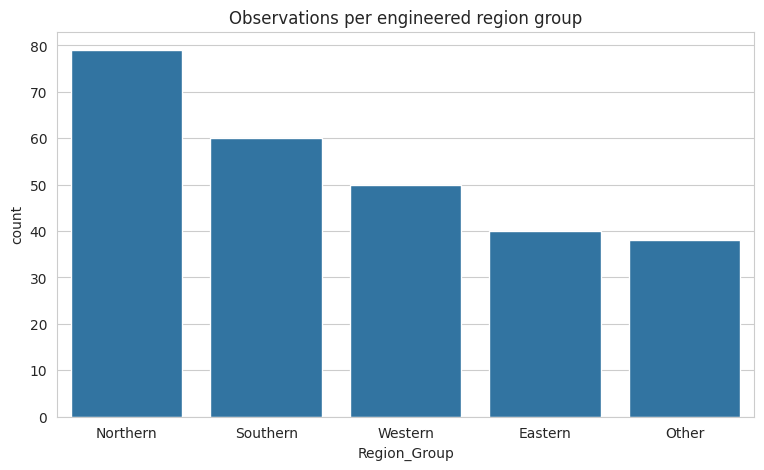

In [25]:
sns.countplot(data=unemp, x="Region_Group",
              order=unemp["Region_Group"].value_counts().index)
plt.title("Observations per engineered region group")
plt.show()

### 2.6 Working with numeric data — cleaning strings into numbers

The course converts `"20,688,070.00"` (a string) into a float. We demonstrate the same `.str.replace()` → `.astype(float)` pipeline on a formatted copy of the employed count.

In [26]:
# Create a messy, comma-formatted string version to clean
messy = unemp["Employed"].map(lambda x: f"{x:,.2f}")
print("Before:", messy.head(3).tolist())

# Remove commas, then cast to float
cleaned = messy.str.replace(",", "", regex=False).astype(float)
print("After: ", cleaned.head(3).tolist(), "->", cleaned.dtype)

Before: ['16,635,535.00', '16,545,652.00', '15,881,197.00']
After:  [16635535.0, 16545652.0, 15881197.0] -> float64


#### Adding descriptive statistics into the DataFrame with `.transform()`

`.transform()` returns a value for **every row** (unlike `.agg()` which collapses groups), so we can attach a group statistic as a new column.

In [27]:
# Standard deviation of unemployment within each zone, attached row-by-row
unemp["zone_std"] = unemp.groupby("Zone")["Unemployment_Rate"].transform(lambda x: x.std())

# Median unemployment by zone, attached row-by-row
unemp["zone_median"] = unemp.groupby("Zone")["Unemployment_Rate"].transform(lambda x: x.median())

unemp[["State", "Zone", "Unemployment_Rate", "zone_median", "zone_std"]].head()

,State,Zone,Unemployment_Rate,zone_median,zone_std
0,Andhra Pradesh,South,5.48,6.045,13.661697
1,Andhra Pradesh,South,5.83,6.045,13.661697
2,Andhra Pradesh,South,5.79,6.045,13.661697
3,Andhra Pradesh,South,20.51,6.045,13.661697
4,Andhra Pradesh,South,17.43,6.045,13.661697


### 2.7 Handling outliers with the IQR method

count    267.000000
mean      12.236929
std       10.803283
min        0.500000
25%        4.845000
50%        9.650000
75%       16.755000
max       75.850000
Name: Unemployment_Rate, dtype: float64


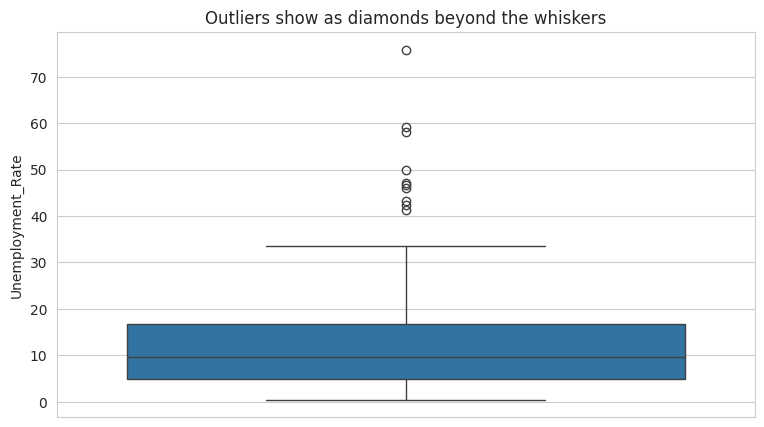

In [28]:
print(unemp["Unemployment_Rate"].describe())

sns.boxplot(data=unemp, y="Unemployment_Rate")
plt.title("Outliers show as diamonds beyond the whiskers")
plt.show()

**IQR rule**

- `IQR = 75th − 25th percentile`
- Upper outliers `> 75th + 1.5 × IQR`
- Lower outliers `< 25th − 1.5 × IQR`

In [29]:
seventy_fifth = unemp["Unemployment_Rate"].quantile(0.75)
twenty_fifth  = unemp["Unemployment_Rate"].quantile(0.25)
iqr = seventy_fifth - twenty_fifth
print("IQR =", iqr)

upper = seventy_fifth + 1.5 * iqr
lower = twenty_fifth - 1.5 * iqr
print("Lower threshold:", lower, "| Upper threshold:", upper)

IQR = 11.91
Lower threshold: -13.020000000000003 | Upper threshold: 34.620000000000005


In [30]:
# Subset the outliers to inspect WHY they are extreme before removing anything
outliers = unemp[(unemp["Unemployment_Rate"] < lower) |
                 (unemp["Unemployment_Rate"] > upper)]
outliers[["State", "Date", "Zone", "Unemployment_Rate"]].sort_values(
    "Unemployment_Rate", ascending=False).head(10)

,State,Date,Zone,Unemployment_Rate
172,Puducherry,30-04-2020,South,75.85
103,Jharkhand,31-05-2020,East,59.23
173,Puducherry,31-05-2020,South,58.19
210,Tamil Nadu,30-04-2020,South,49.83
102,Jharkhand,30-04-2020,East,47.09
23,Bihar,30-04-2020,East,46.64
24,Bihar,31-05-2020,East,45.96
73,Haryana,30-04-2020,North,43.22
44,Delhi,31-05-2020,North,42.27
230,Tripura,30-04-2020,Northeast,41.23


In [31]:
# These spikes coincide with the 2020 lockdown -> genuine, not errors.
# Course guidance: understand them first; remove only if they are data errors.
no_outliers = unemp[(unemp["Unemployment_Rate"] > lower) &
                    (unemp["Unemployment_Rate"] < upper)]
print(f"Original rows: {len(unemp)}  |  Without outliers: {len(no_outliers)}")
print(no_outliers["Unemployment_Rate"].describe())

Original rows: 267  |  Without outliers: 257
count    257.000000
mean      10.730545
std        7.511435
min        0.500000
25%        4.690000
50%        9.230000
75%       15.740000
max       33.500000
Name: Unemployment_Rate, dtype: float64


---
# Chapter 3 — Relationships in Data

How variables relate: over time, in strength (correlation), and in distribution.

### 3.1 Importing DateTime data & updating the type

In [32]:
# Convert the string Date to a real datetime (fixing the issue from Ch.1)
unemp["Date"] = pd.to_datetime(unemp["Date"], format="%d-%m-%Y")

# Extract components that are useful for grouping
unemp["month"] = unemp["Date"].dt.month
unemp["month_name"] = unemp["Date"].dt.month_name()

print(unemp["Date"].dtype)
unemp[["State", "Date", "month", "month_name"]].head()

datetime64[ns]


,State,Date,month,month_name
0,Andhra Pradesh,2020-01-31,1,January
1,Andhra Pradesh,2020-02-29,2,February
2,Andhra Pradesh,2020-03-31,3,March
3,Andhra Pradesh,2020-04-30,4,April
4,Andhra Pradesh,2020-05-31,5,May


### 3.2 Visualizing relationships over time

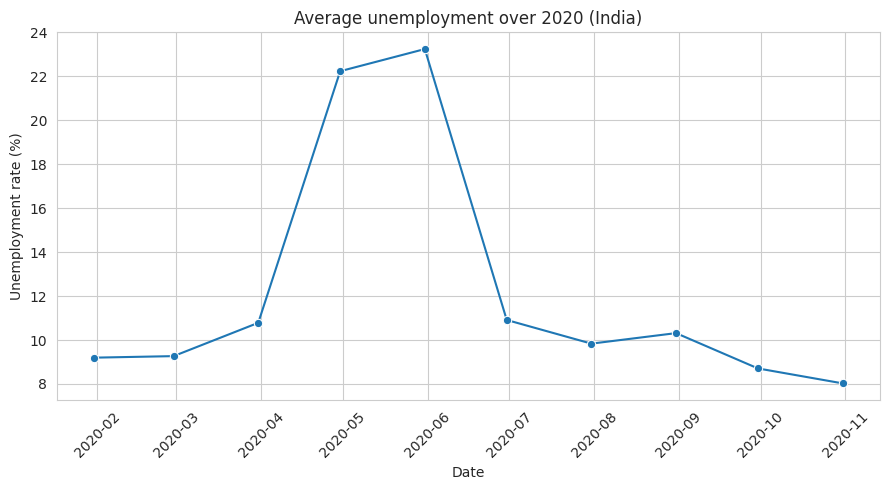

In [33]:
# National average unemployment per month -> the lockdown spike is clear
monthly = unemp.groupby("Date")["Unemployment_Rate"].mean().reset_index()

sns.lineplot(data=monthly, x="Date", y="Unemployment_Rate", marker="o")
plt.title("Average unemployment over 2020 (India)")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

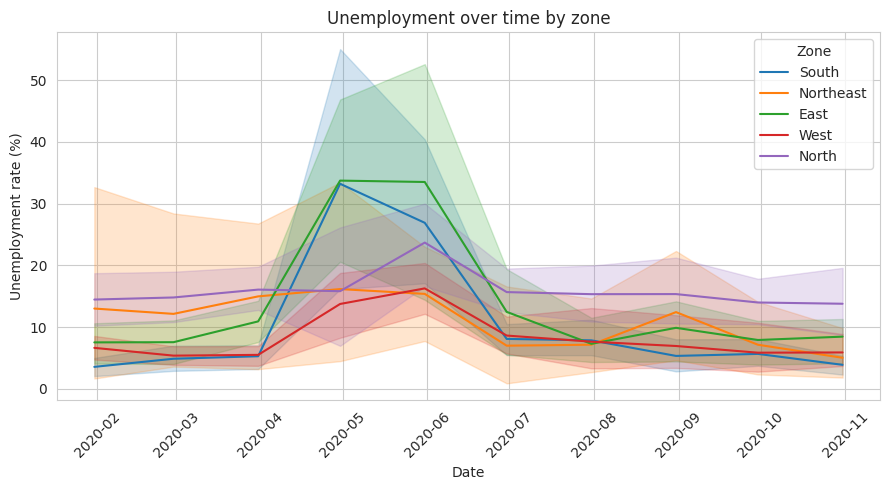

In [34]:
# Same trend split by zone
sns.lineplot(data=unemp, x="Date", y="Unemployment_Rate", hue="Zone")
plt.title("Unemployment over time by zone")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Correlation & a heatmap

In [35]:
# Pearson correlation between the numeric measures
num_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr = unemp[num_cols].corr()
print(corr)

                           Unemployment_Rate  Employed  \
Unemployment_Rate                   1.000000 -0.245176   
Employed                           -0.245176  1.000000   
Labour_Participation_Rate          -0.073540 -0.047948   

                           Labour_Participation_Rate  
Unemployment_Rate                          -0.073540  
Employed                                   -0.047948  
Labour_Participation_Rate                   1.000000  


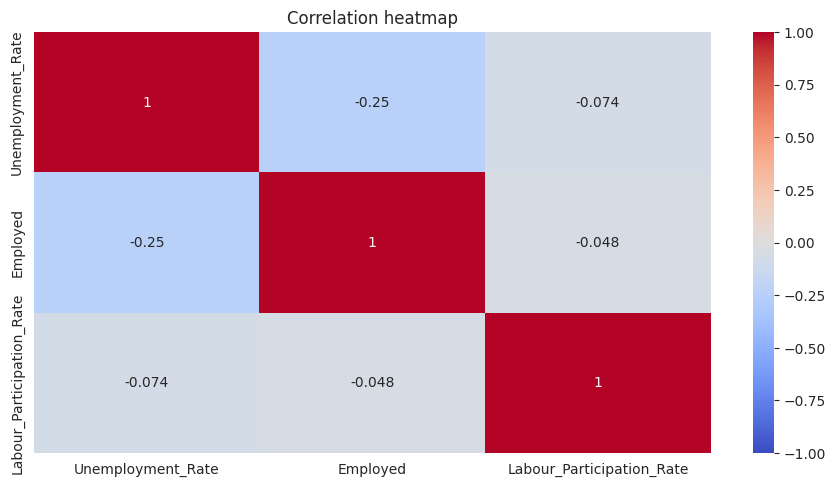

In [36]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Reading the heatmap:** values near +1 move together, near −1 move oppositely, near 0 are unrelated. Unemployment and labour participation are negatively related — as more people drop out of the labour force, the measured rate shifts.

### 3.4 Visualizing variable relationships — scatter & pairplot

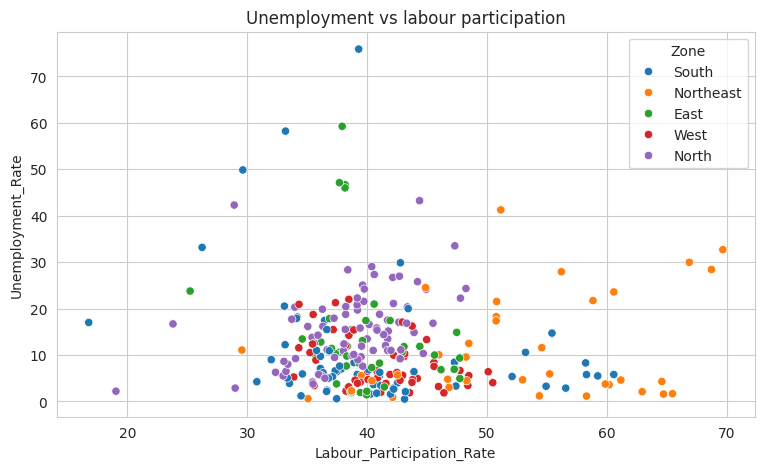

In [37]:
sns.scatterplot(data=unemp, x="Labour_Participation_Rate",
                y="Unemployment_Rate", hue="Zone")
plt.title("Unemployment vs labour participation")
plt.show()

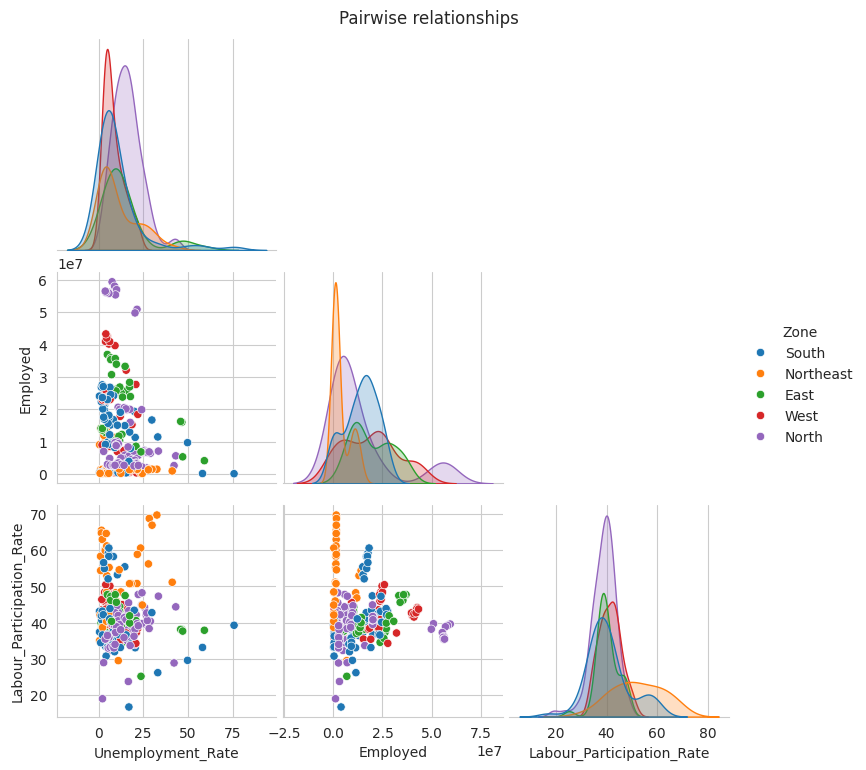

In [38]:
# Multiple relationships at once
sns.pairplot(unemp[num_cols + ["Zone"]], hue="Zone", corner=True)
plt.suptitle("Pairwise relationships", y=1.02)
plt.show()

### 3.5 Factor relationships & distributions — categorical scatter and KDE

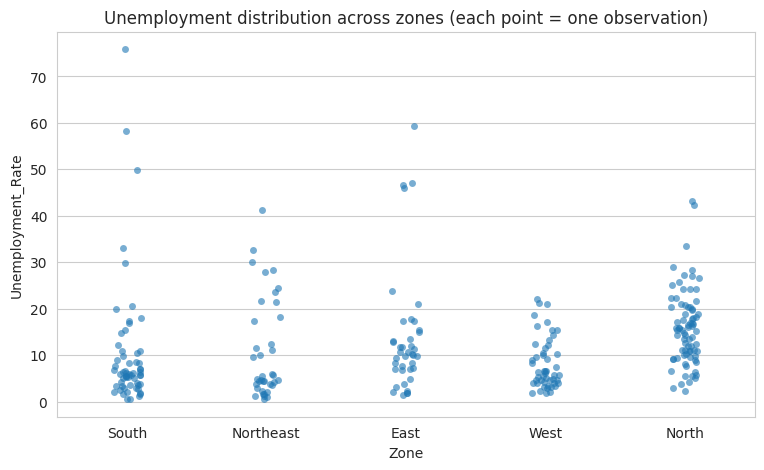

In [39]:
# Categorical data in a scatter-style view
sns.stripplot(data=unemp, x="Zone", y="Unemployment_Rate", alpha=0.6)
plt.title("Unemployment distribution across zones (each point = one observation)")
plt.show()

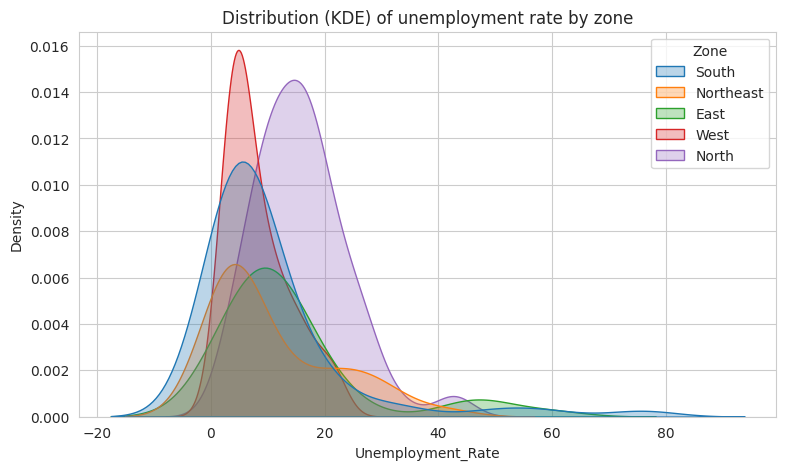

In [40]:
# KDE plot: smoothed distribution of unemployment, one curve per zone
sns.kdeplot(data=unemp, x="Unemployment_Rate", hue="Zone", fill=True, alpha=0.3)
plt.title("Distribution (KDE) of unemployment rate by zone")
plt.show()

---
# Chapter 4 — Turning Exploratory Analysis into Action

Class balance, cross-tabulation, feature generation, and forming hypotheses.

### 4.1 Considerations for categorical data — checking for class imbalance

In [41]:
# Relative frequency of each region group (normalize -> proportions)
print(unemp["Region_Group"].value_counts(normalize=True).round(3))

Region_Group
Northern    0.296
Southern    0.225
Western     0.187
Eastern     0.150
Other       0.142
Name: proportion, dtype: float64


If one class dominates, downstream models can become biased toward it — worth knowing before modelling.

### 4.2 Cross-tabulation

In [42]:
# First, bucket unemployment into labelled bands so we have two categoricals
unemp["rate_band"] = pd.cut(
    unemp["Unemployment_Rate"],
    bins=[0, 5, 10, 20, 100],
    labels=["Low", "Moderate", "High", "Very High"],
)

# Cross-tab: how bands distribute across zones
pd.crosstab(unemp["Zone"], unemp["rate_band"])

rate_band,Low,Moderate,High,Very High
Zone,,,,
East,8,11,15,6
North,5,14,39,21
Northeast,19,4,6,9
South,20,24,10,6
West,19,16,12,3


In [43]:
# Cross-tab can also aggregate a value: mean employed per Zone x band
pd.crosstab(unemp["Zone"], unemp["rate_band"],
            values=unemp["Employed"], aggfunc="mean").round(0)

rate_band,Low,Moderate,High,Very High
Zone,,,,
East,16670471.0,24714899.0,21438101.0,9549250.0
North,24763796.0,23627537.0,9309938.0,10239736.0
Northeast,4862335.0,5649017.0,2055660.0,1126180.0
South,17466176.0,14179523.0,10325569.0,8257930.0
West,25731924.0,17892440.0,9123219.0,15503808.0


### 4.3 Generating new features

In [44]:
# Feature 1: extract time parts (already have month) -> add quarter
unemp["quarter"] = unemp["Date"].dt.quarter

# Feature 2: percentile-based categories (course's 'Calculating salary percentiles')
percentiles = unemp["Unemployment_Rate"].quantile([0.25, 0.5, 0.75]).tolist()
labels = ["Q1_lowest", "Q2", "Q3", "Q4_highest"]
unemp["rate_quartile"] = pd.cut(
    unemp["Unemployment_Rate"],
    bins=[unemp["Unemployment_Rate"].min() - 1] + percentiles + [unemp["Unemployment_Rate"].max() + 1],
    labels=labels,
)

unemp[["State", "Date", "Unemployment_Rate", "quarter", "rate_quartile"]].head()

,State,Date,Unemployment_Rate,quarter,rate_quartile
0,Andhra Pradesh,2020-01-31,5.48,1,Q2
1,Andhra Pradesh,2020-02-29,5.83,1,Q2
2,Andhra Pradesh,2020-03-31,5.79,1,Q2
3,Andhra Pradesh,2020-04-30,20.51,2,Q4_highest
4,Andhra Pradesh,2020-05-31,17.43,2,Q4_highest


### 4.4 Extracting features for correlation

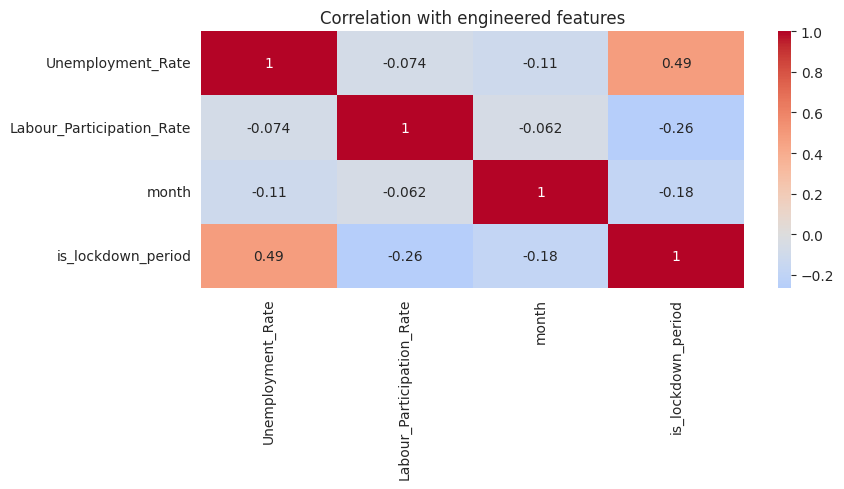

In [45]:
# Turn a datetime feature into something correlatable, then re-check correlation
unemp["is_lockdown_period"] = unemp["month"].isin([4, 5]).astype(int)

corr_features = unemp[["Unemployment_Rate", "Labour_Participation_Rate",
                       "month", "is_lockdown_period"]].corr()
sns.heatmap(corr_features, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with engineered features")
plt.tight_layout()
plt.show()

### 4.5 Generating hypotheses — comparing groups

In [46]:
# Compare average unemployment: lockdown months (Apr-May) vs the rest
comparison = unemp.groupby("is_lockdown_period")["Unemployment_Rate"].agg(["mean", "median", "count"])
comparison.index = ["Other months", "Lockdown (Apr-May)"]
print(comparison)

                         mean  median  count
Other months         9.633271   7.615    214
Lockdown (Apr-May)  22.749811  18.710     53


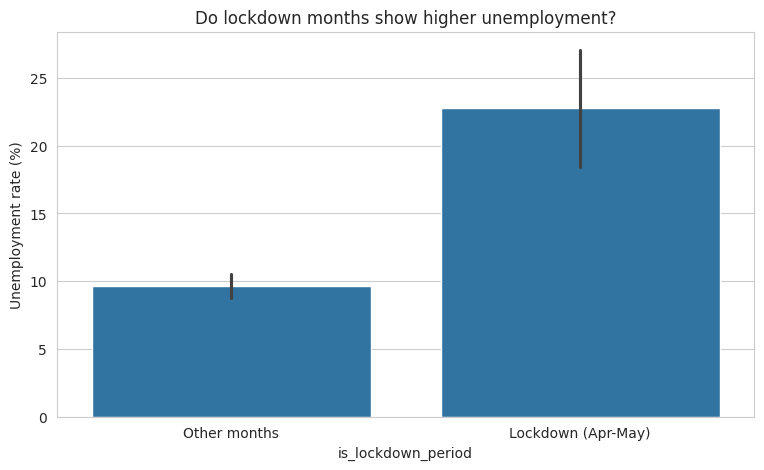

In [47]:
sns.barplot(data=unemp, x="is_lockdown_period", y="Unemployment_Rate")
plt.xticks([0, 1], ["Other months", "Lockdown (Apr-May)"])
plt.title("Do lockdown months show higher unemployment?")
plt.ylabel("Unemployment rate (%)")
plt.show()

### 4.6 Choosing a hypothesis

From the exploration above, several testable hypotheses emerge:

1. **Lockdown effect** — Unemployment during Apr–May 2020 is significantly higher than in other months.
2. **Regional gap** — Northern-zone unemployment is systematically higher than Western-zone unemployment.
3. **Participation trade-off** — Higher labour-participation rates are associated with lower measured unemployment.

Each is now a concrete, testable claim — the natural hand-off from EDA into statistical testing or modelling. **That is the goal of exploratory analysis: not an end in itself, but the foundation for the questions worth answering next.**

---
## Summary

| Chapter | Techniques practised |
|---|---|
| **1. Getting to know the data** | `.head()`, `.info()`, `.describe()`, `.value_counts()`, `.nunique()`, `.isin()`, `.groupby().agg()`, named aggregations, `countplot`, `barplot` |
| **2. Cleaning & manipulation** | `.isna().sum()`, threshold-based drops, mean/median/mode & sub-group imputation, `.str.contains()`, `np.select()`, `.str.replace()`, `.astype()`, `.transform()`, IQR outliers |
| **3. Relationships** | `pd.to_datetime()`, `.dt` accessors, `lineplot`, `.corr()`, heatmap, `scatterplot`, `pairplot`, `stripplot`, `kdeplot` |
| **4. Action** | class-imbalance checks, `pd.crosstab()`, feature generation, `pd.cut()` percentile bands, correlation of engineered features, group comparison, hypothesis framing |


---
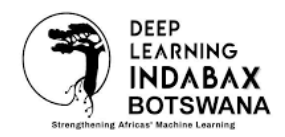

**Deep Learning IndabaX Botswana** — *Strengthening Africa's Machine Learning*

*You've now applied the full EDA workflow end to end: explore → clean → find relationships → act. The natural next step is statistical testing or modelling on the hypotheses generated above.*
